In [3]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Import ONLY the engine and the circuit from your friend's file
from l_vqe_functions import simulate_one_lvqe, _apply_lvqe_circuit

=== SETUP: 5-Node Max-Cut ===


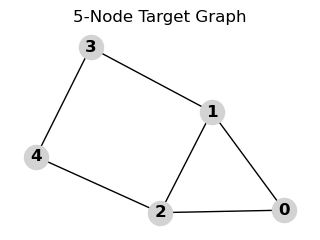

Hamiltonian initialized for 5 qubits over 6 edges.


In [4]:
print("=== SETUP: 5-Node Max-Cut ===")

# 1. Map the 5-node diagram (0: Left, 1: Top-mid, 2: Bot-mid, 3: Top-right, 4: Bot-right)
G_5 = nx.Graph()
G_5.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4)])
n_qubits = len(G_5.nodes)  # Max-Cut requires exactly 1 qubit per node (k=2)

# Draw it to verify the geometry
plt.figure(figsize=(3, 2))
nx.draw(G_5, with_labels=True, node_color='lightgray', font_weight='bold')
plt.title("5-Node Target Graph")
plt.show()

# 2. Define the EXACT Max-Cut Hamiltonian
def create_exact_maxcut_hamiltonian(graph):
    """Minimizing this Hamiltonian directly outputs the negative number of cuts."""
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(-0.5)
        observables.append(qml.Identity(u)) 
        
        coeffs.append(0.5)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
        
    return qml.Hamiltonian(coeffs, observables)

H_maxcut = create_exact_maxcut_hamiltonian(G_5)
print(f"Hamiltonian initialized for {n_qubits} qubits over {len(G_5.edges)} edges.")

=== RUNNING L-VQE ENGINE ===
  Layer 0  (5 params) ... cost = -4.997500
  Layer 1  (21 params) ... cost = -5.000000
  Layer 2  (37 params) ... cost = -5.000000

Final Cost (Number of Cuts): 5.00 out of 6


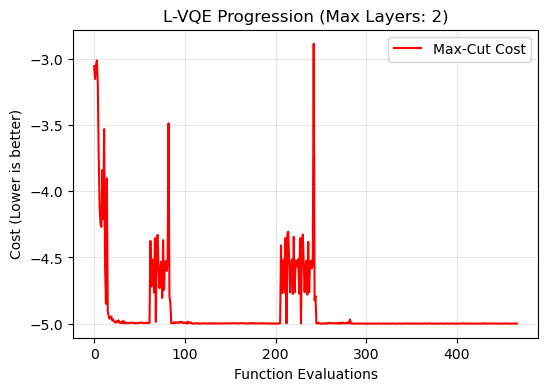


=== DECODING QUANTUM STATE ===
Top 3 Most Probable Node Groupings:
----------------------------------------
Bitstring: |01001⟩ | Probability:  99.8%
  -> Set 0: [0, 2, 3]
  -> Set 1: [1, 4]

Bitstring: |11001⟩ | Probability:   0.1%
  -> Set 0: [2, 3]
  -> Set 1: [0, 1, 4]

Bitstring: |00101⟩ | Probability:   0.0%
  -> Set 0: [0, 1, 3]
  -> Set 1: [2, 4]



In [8]:
print("=== RUNNING L-VQE ENGINE ===")

# 1. Run the simulation using your friend's engine
max_layers = 2
shots = 4000
rng = np.random.default_rng(42)

results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_maxcut,
    max_layers=max_layers,
    shots=shots,
    max_iter_per_layer=200,
    rng=rng
)

trained_params = results["final_params"]
cost_history = results["cost_history"]
print(f"\nFinal Cost (Number of Cuts): {-results['final_cost']:.2f} out of {len(G_5.edges)}")

# 2. Plot the Optimization Curve
plt.figure(figsize=(6, 4))
plt.plot(cost_history, label="Max-Cut Cost", color='red')
plt.title(f"L-VQE Progression (Max Layers: {max_layers})")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Lower is better)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3. Decode the Winning State
print("\n=== DECODING QUANTUM STATE ===")
dev_read = qml.device("default.qubit", wires=n_qubits, shots=shots)

@qml.qnode(dev_read)
def read_circuit(params):
    # Use your friend's private circuit function to rebuild the final state
    _apply_lvqe_circuit(params, n_qubits, max_layers)
    return qml.counts()

counts = read_circuit(trained_params)
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("Top 3 Most Probable Node Groupings:")
print("-" * 40)
for bitstring, count in sorted_counts[:3]:
    prob = (count / shots) * 100
    print(f"Bitstring: |{bitstring}⟩ | Probability: {prob:5.1f}%")
    
    # Optional: Map the 0s and 1s back to physical nodes
    group_0 = [node for node, bit in enumerate(bitstring) if bit == '0']
    group_1 = [node for node, bit in enumerate(bitstring) if bit == '1']
    print(f"  -> Set 0: {group_0}")
    print(f"  -> Set 1: {group_1}\n")